<a href="https://colab.research.google.com/github/maps-05/portfolio/blob/main/Personnel_DataAnalysis_and_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

RELATIVO, Muffle P.

BsCPE III GE

## Personnel Data Analysis and Clustering

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load Dataset

data = {
    "TRANSACTION": [
        "T1", "T2", "T3", "T4", "T5",
        "T6", "T7", "T8", "T9", "T10",
        "T11", "T12", "T13", "T14", "T15"
    ],
    "ITEMS": [
        ["B", "D", "A", "E", "G", "C"],
        ["C", "G", "F", "B", "E"],
        ["G", "B", "F", "A"],
        ["B", "G", "E", "F"],
        ["C", "F", "D", "E", "A", "B", "G"],
        ["E", "D", "C", "F", "G", "B"],
        ["A", "G", "F", "E", "D"],
        ["F", "D", "A", "C", "B"],
        ["F", "C", "D", "G"],
        ["D", "F", "A", "B", "C", "G"],
        ["G", "A", "F", "D", "B", "E", "C"],
        ["A", "C", "B", "D", "G", "E"],
        ["E", "F", "G", "C", "D", "B", "A"],
        ["A", "F", "E", "B", "C"],
        ["F", "B", "A", "G", "D", "C", "E"]
    ]
}

# Convert into DataFrame
df = pd.DataFrame(data)
df_indexed = df.set_index("TRANSACTION")
df_indexed

,ITEMS
TRANSACTION,
T1,"[B, D, A, E, G, C]"
T2,"[C, G, F, B, E]"
T3,"[G, B, F, A]"
T4,"[B, G, E, F]"
T5,"[C, F, D, E, A, B, G]"
T6,"[E, D, C, F, G, B]"
T7,"[A, G, F, E, D]"
T8,"[F, D, A, C, B]"
T9,"[F, C, D, G]"


In [ ]:
# Total number of transactions
total_transactions = len(df_indexed)

def support(itemset):
    count = sum(1 for items in df_indexed["ITEMS"] if set(itemset).issubset(set(items)))
    return count / total_transactions

def confidence(X, Y):
    return support(X + Y) / support(X)

def lift(X, Y):
    return confidence(X, Y) / support(Y)

# 1
sup_BFE = support(["B", "F", "E"])

# 2
sup_CEA = support(["C", "E", "A"])

# 3
lift_AG_C = lift(["A", "G"], ["C"])

# 4
lift_DCB_A = lift(["D", "C", "B"], ["A"])

# 5
conf_GDE_B = confidence(["G", "D", "E"], ["B"])

sup_BFE, sup_CEA, lift_AG_C, lift_DCB_A, conf_GDE_B

(0.5333333333333333,
 0.4666666666666667,
 0.9722222222222222,
 1.2121212121212124,
 0.875)

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/personnel_data.csv')
df.head()

,EmployeeID,Age,Experience,EducationLevel,Salary,JobSatisfaction,Department,ProjectsHandled,PromotionLast5Years
0,1,50,1,2,33.07,3,5,10,0
1,2,36,4,1,19.37,7,1,11,0
2,3,29,28,1,52.64,8,1,5,1
3,4,42,18,3,60.37,10,4,8,0
4,5,40,7,1,28.94,6,3,15,0


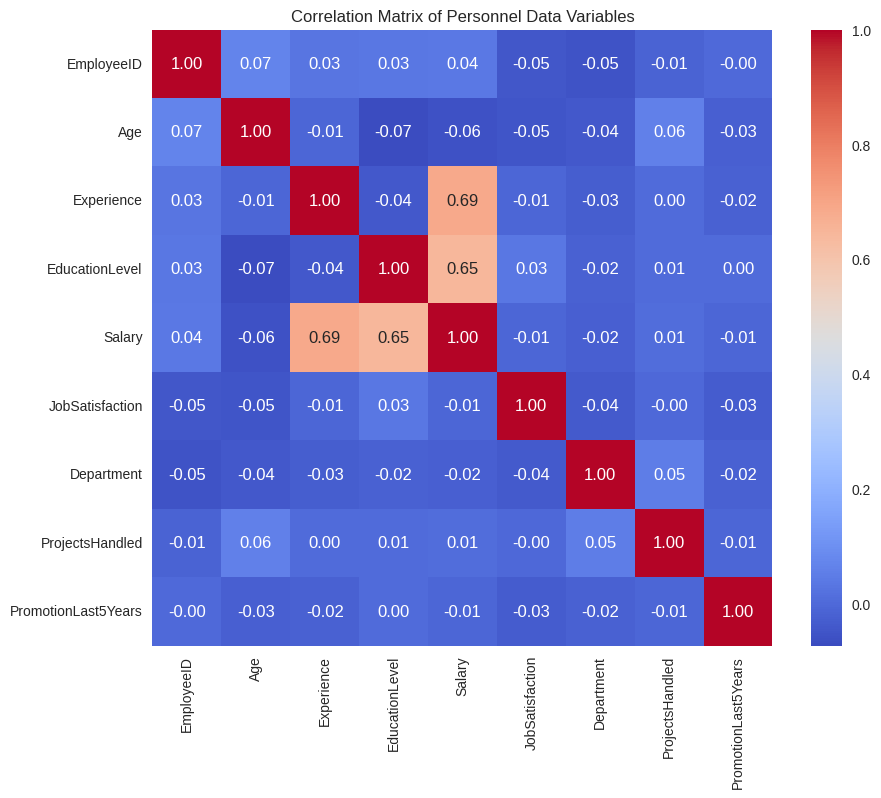

In [ ]:
# Calculate the correlation matrix
correlation_matrix = df.corr()

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Personnel Data Variables')
plt.show()

In [ ]:
# SCALED DATA

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
df_scaled

array([[-1.72859016,  0.78600972, -1.53699054, ...,  1.36744578,
         0.00997174, -0.50624244],
       [-1.72166195, -0.48204007, -1.25431695, ..., -1.43469722,
         0.17080633, -0.50624244],
       [-1.71473373, -1.11606497,  1.00707178, ..., -1.43469722,
        -0.79420116,  1.97533814],
       ...,
       [ 1.71473373, -0.66319004, -1.44276601, ..., -0.03362572,
        -0.79420116, -0.50624244],
       [ 1.72166195, -1.02548998,  0.53594913, ...,  1.36744578,
         1.61831756, -0.50624244],
       [ 1.72859016,  0.60485975,  0.4417246 , ..., -0.73416147,
         0.81414465, -0.50624244]])

In [ ]:
df_scaled = pd.DataFrame(df_scaled, columns = df.columns)
df_scaled.tail()

,EmployeeID,Age,Experience,EducationLevel,Salary,JobSatisfaction,Department,ProjectsHandled,PromotionLast5Years
495,1.700877,1.601185,-0.971643,-0.202539,-0.975849,-1.238043,-1.434697,-1.598374,-0.506242
496,1.707806,-1.206640,-1.631215,-0.202539,-1.184447,0.878270,-1.434697,-0.794201,-0.506242
497,1.714734,-0.663190,-1.442766,-0.202539,-1.115654,-0.179887,-0.033626,-0.794201,-0.506242
498,1.721662,-1.025490,0.535949,-0.202539,-0.022180,0.525551,1.367446,1.618318,-0.506242
499,1.728590,0.604860,0.441725,-1.452777,-0.897625,-0.532606,-0.734161,0.814145,-0.506242


In [ ]:
correlation_matrix_new = df_scaled.corr()
correlation_matrix_new

,EmployeeID,Age,Experience,EducationLevel,Salary,JobSatisfaction,Department,ProjectsHandled,PromotionLast5Years
EmployeeID,1.000000,0.066858,0.028131,0.032318,0.037729,-0.045495,-0.052379,-0.014754,-0.000894
Age,0.066858,1.000000,-0.009887,-0.073172,-0.057021,-0.048376,-0.041589,0.059960,-0.026902
Experience,0.028131,-0.009887,1.000000,-0.041060,0.686259,-0.009742,-0.030428,0.003324,-0.020027
EducationLevel,0.032318,-0.073172,-0.041060,1.000000,0.645446,0.033241,-0.019072,0.006041,0.002954
Salary,0.037729,-0.057021,0.686259,0.645446,1.000000,-0.009889,-0.024281,0.009303,-0.009194
JobSatisfaction,-0.045495,-0.048376,-0.009742,0.033241,-0.009889,1.000000,-0.038665,-0.003085,-0.033296
Department,-0.052379,-0.041589,-0.030428,-0.019072,-0.024281,-0.038665,1.000000,0.050586,-0.020500
ProjectsHandled,-0.014754,0.059960,0.003324,0.006041,0.009303,-0.003085,0.050586,1.000000,-0.007724
PromotionLast5Years,-0.000894,-0.026902,-0.020027,0.002954,-0.009194,-0.033296,-0.020500,-0.007724,1.000000


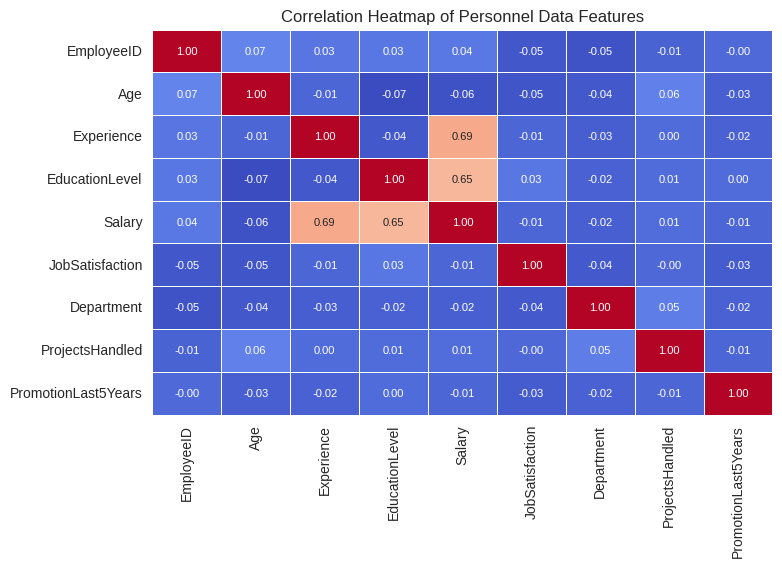

In [ ]:
plt.figure(figsize = (8,5))
sns.heatmap(correlation_matrix, annot = True, cmap = 'coolwarm', linewidths = 0.5, fmt = '.2f', annot_kws={"size": 8}, cbar = False)
plt.title("Correlation Heatmap of Personnel Data Features")
plt.show()

In [ ]:
reduced_data_scaled = df_scaled.drop(columns=['EmployeeID', 'PromotionLast5Years', 'Experience'])
reduced_data_scaled.tail()

,Age,EducationLevel,Salary,JobSatisfaction,Department,ProjectsHandled
495,1.601185,-0.202539,-0.975849,-1.238043,-1.434697,-1.598374
496,-1.206640,-0.202539,-1.184447,0.878270,-1.434697,-0.794201
497,-0.663190,-0.202539,-1.115654,-0.179887,-0.033626,-0.794201
498,-1.025490,-0.202539,-0.022180,0.525551,1.367446,1.618318
499,0.604860,-1.452777,-0.897625,-0.532606,-0.734161,0.814145


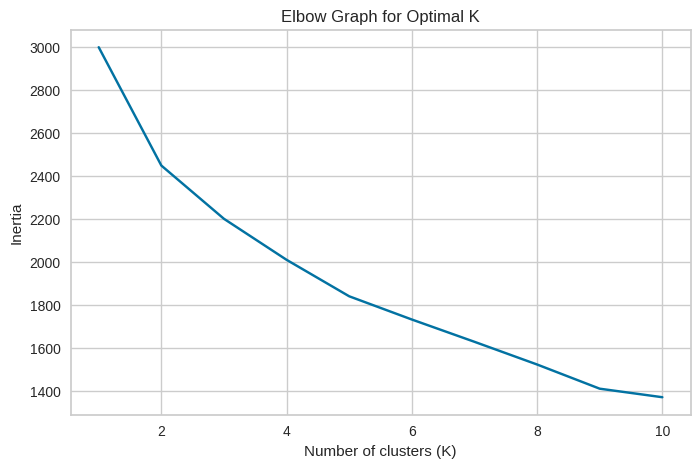

In [ ]:
from sklearn.cluster import KMeans

inertia = []

K = range(1, 11)

for k in K: # test 10 Ks

  model = KMeans(n_clusters = k, random_state = 101, n_init = 'auto')
  model.fit(reduced_data_scaled)
  inertia.append(model.inertia_)

# Plot the elbow curve

plt.figure(figsize = (8,5))
plt.plot(K, inertia)
plt.title('Elbow Graph for Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.show()


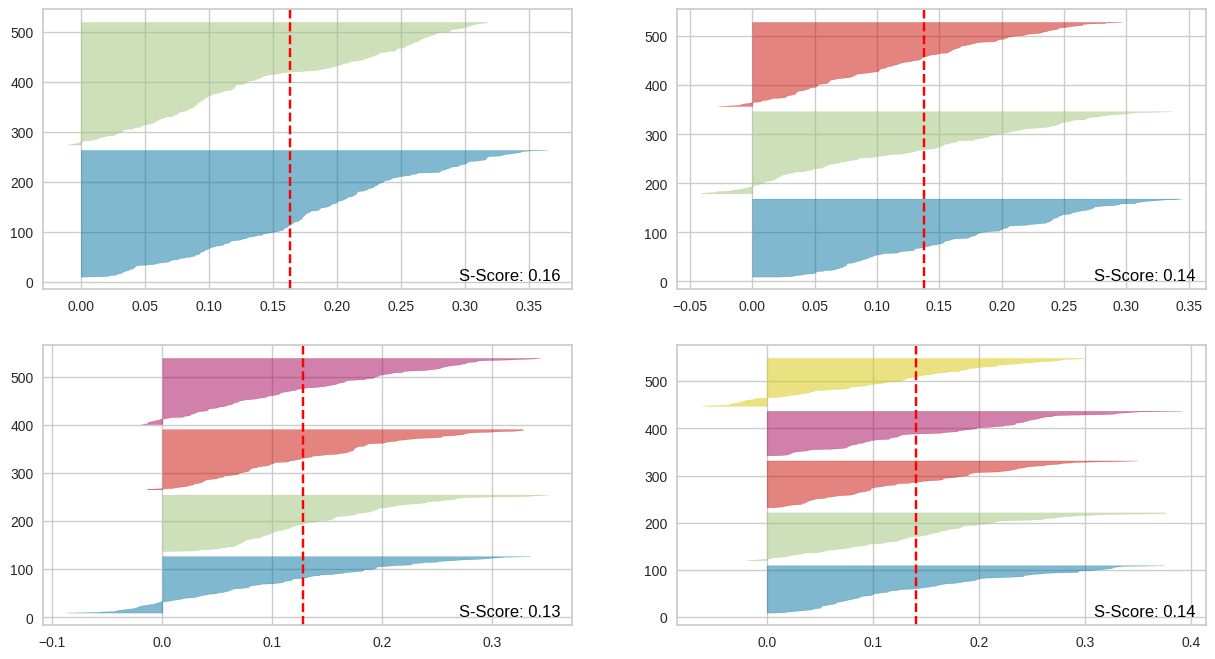

In [ ]:
from yellowbrick.cluster import SilhouetteVisualizer

fig, ax = plt.subplots(2,2, figsize = (15,8))

for i in [2, 3, 4, 5]:

  km = KMeans(n_clusters = i, random_state = 101, n_init = 'auto')
  q, mod = divmod(i, 2)

  # Create SilhouetteVisualizer

  visualizer = SilhouetteVisualizer(km, colors = 'yellowbrick', ax = ax[q - 1][mod])
  visualizer.fit(reduced_data_scaled)

  silhouette_score = visualizer.silhouette_score_
  ax[q - 1][mod].text(0.98, 0.02, f'S-Score: {silhouette_score:.2f}',
                      transform = ax[q - 1][mod].transAxes,
                      ha='right', va='bottom', fontsize=12, color='black')

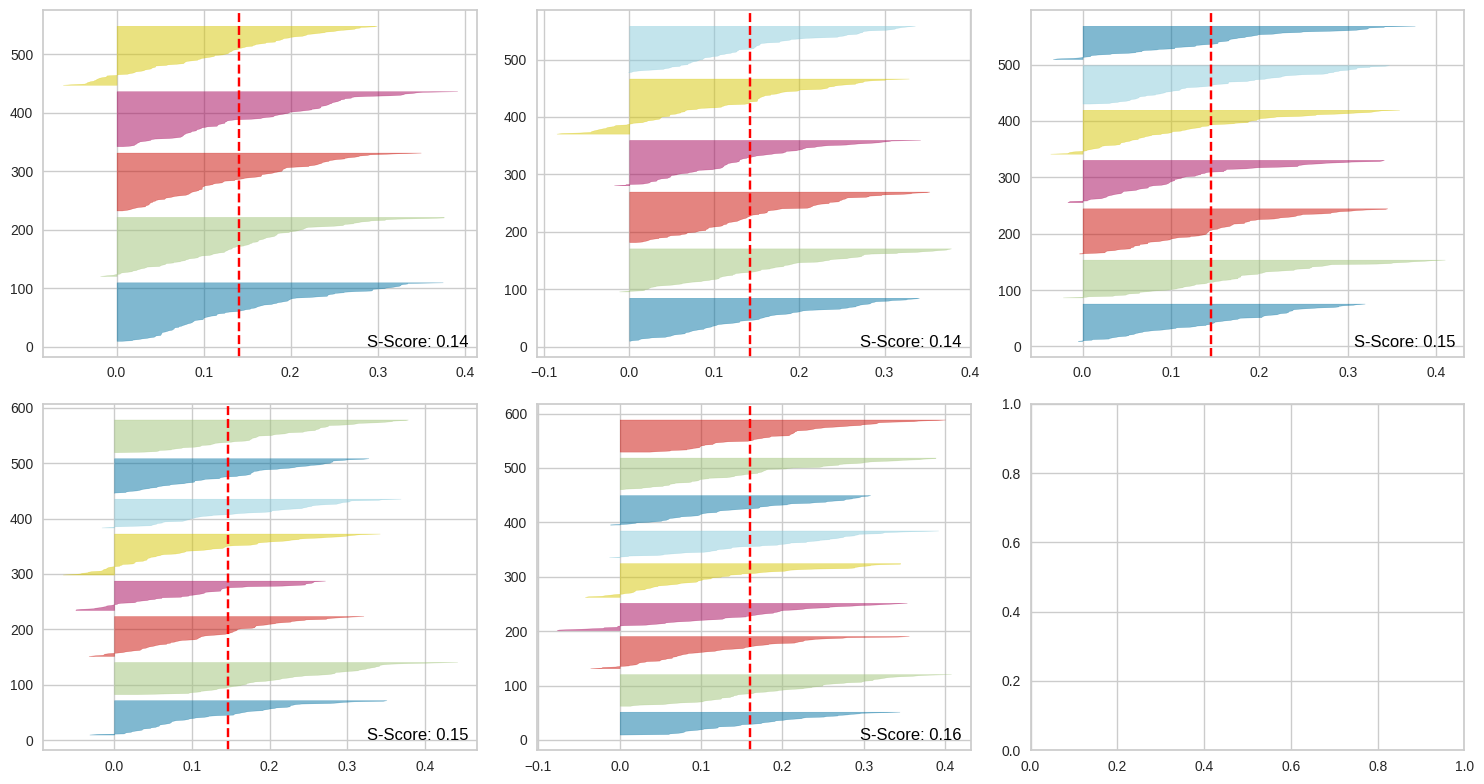

In [ ]:
from yellowbrick.cluster import SilhouetteVisualizer

fig, ax = plt.subplots(2,3, figsize = (15,8))

for i in range(5, 10): # test K from 5 to 9

  km = KMeans(n_clusters = i, random_state = 101, n_init = 'auto')
  q, mod = divmod(i-5, 3)

  # Create SilhouetteVisualizer

  visualizer = SilhouetteVisualizer(km, colors = 'yellowbrick', ax = ax[q][mod])
  visualizer.fit(reduced_data_scaled)

  silhouette_score = visualizer.silhouette_score_
  ax[q][mod].text(0.98, 0.02, f'S-Score: {silhouette_score:.2f}',
                      transform = ax[q][mod].transAxes,
                      ha='right', va='bottom', fontsize=12, color='black')

plt.tight_layout() #
plt.show()

In [ ]:
# Assign n_clusters = 2

final_model = KMeans(n_clusters = 2, random_state = 101, n_init = 'auto')
reduced_data_scaled['Cluster'] = final_model.fit_predict(reduced_data_scaled)
reduced_data_scaled


,Age,EducationLevel,Salary,JobSatisfaction,Department,ProjectsHandled,Cluster
0,0.786010,-0.202539,-1.112326,-0.885324,1.367446,0.009972,0
1,-0.482040,-1.452777,-1.872376,0.525551,-1.434697,0.170806,0
2,-1.116065,-1.452777,-0.026618,0.878270,-1.434697,-0.794201,0
3,0.061410,1.047700,0.402228,1.583708,0.666910,-0.311697,1
4,-0.119740,-1.452777,-1.341450,0.172832,-0.033626,0.814145,0
...,...,...,...,...,...,...,...
495,1.601185,-0.202539,-0.975849,-1.238043,-1.434697,-1.598374,0
496,-1.206640,-0.202539,-1.184447,0.878270,-1.434697,-0.794201,0
497,-0.663190,-0.202539,-1.115654,-0.179887,-0.033626,-0.794201,0
498,-1.025490,-0.202539,-0.022180,0.525551,1.367446,1.618318,1


In [ ]:
employee_305_cluster = reduced_data_scaled.loc[304, 'Cluster']
print(f"Data for EmployeeID 305 belongs to Cluster: {employee_305_cluster}")

display(reduced_data_scaled)

Data for EmployeeID 305 belongs to Cluster: 1


,Age,EducationLevel,Salary,JobSatisfaction,Department,ProjectsHandled,Cluster
0,0.786010,-0.202539,-1.112326,-0.885324,1.367446,0.009972,0
1,-0.482040,-1.452777,-1.872376,0.525551,-1.434697,0.170806,0
2,-1.116065,-1.452777,-0.026618,0.878270,-1.434697,-0.794201,0
3,0.061410,1.047700,0.402228,1.583708,0.666910,-0.311697,1
4,-0.119740,-1.452777,-1.341450,0.172832,-0.033626,0.814145,0
...,...,...,...,...,...,...,...
495,1.601185,-0.202539,-0.975849,-1.238043,-1.434697,-1.598374,0
496,-1.206640,-0.202539,-1.184447,0.878270,-1.434697,-0.794201,0
497,-0.663190,-0.202539,-1.115654,-0.179887,-0.033626,-0.794201,0
498,-1.025490,-0.202539,-0.022180,0.525551,1.367446,1.618318,1


### Conclusion

Based on the KMeans clustering with an optimal number of 2 clusters, the personnel data has been segmented into two distinct groups. EmployeeID 305, for example, has been assigned to Cluster 1. Further analysis of the cluster centroids would be necessary to understand the characteristics and differentiating factors of each cluster. This clustering can be valuable for targeted HR strategies, personalized development plans, or identifying specific groups within the workforce.